### Group Members:

- Emanuel Frank, 16.466.021
- Arianna Rostan, 25.750.894
- Name, matriculation number

# Assignment 1: Universal Function Approximator


The goal of this exercise is to compare three different neural network architectures and analyze their capacity for function approximation:

1. $N_0$: One-layer network (linear transformation only)
2. $N_1$: One-layer network with non-linear activation function
3. $N_2$: Two-layer network (hidden layer with non-linear activation function)

They will be trained via gradient descent with weight decay.
To show the flexibility of the approach, three different functions will be approximated:
1. $X_0: t = \sin(2x)$ for $x\in[-2,2]$
2. $X_1: t = e^{-x^2}$ for $x\in[-3,3]$
3. $X_2: t = -x^5 - 3x^4 + 11x^3 +27x^2 - 10x - 32$ for $x\in[-4.5,3.5]$

In the theoretical section, the networks will be designed, and the necessary derivatives will be computed by hand.

In the coding section, we will:

- implement the networks and their gradients,
- generate target data for three different functions,
- apply the training procedure to the data, and
- plot the resulting approximated function together with the data samples.

## Section 1: Theoretical Questions

### Network Design

#### Task 1.1: Network Structure

Given input $\vec x = (1, x)^T$, define three neural networks ($N_0$, $N_1$, $N_2$) mathematically, to reach output $y$. Use $g()$ to represent the activation function.

Explain how their structures differ and analyze their function approximation capabilities.

--- 
Note:

For one-layer networks, define parameter $\Theta=\vec w \in\mathbb R^{D+1}$

For two-layer network, define parameters $\Theta=(\mathbf W^{(1)},\vec w^{(2)})$ that are split into $\mathbf W^{(1)}\in\mathbb R^{K\times {(D+1)}}$ for the first layer and $\vec w^{(2)}\in\mathbb R^{K+1}$ for the second layer

$N_0$: $N_0(\tilde{x};\Theta)=\vec w^{\,T}\tilde{x}=w_0+w_1x$

$N_1$: $N_1(\tilde{x};\Theta)=g(\vec w^{\,T}\tilde{x})=g(w_0+w_1x)$

$N_2$: $N_2(\tilde{x};\Theta)=w_0^{(2)}+\sum_{k=1}^K w_k^{(2)}\, g\!\left(w_{k,0}^{(1)}+w_{k,1}^{(1)}x\right)$

#### How do their structure differ?
$N_0$ does not need a activation function since it is a purely linear model. It has only one affine/linear transformation. The output is always a straight line in $x$

$N_1$ has still only one layer of parameters but now a non-linear activation function $g()$ is applied once. This will end in the output having the form $N_1(x) = g(w_0 + w_1 x)$. So it is more flexible than $N_0$, but still very restricted because it is only one activated affine function.

$N_2$ has a hidden layer with $K$ neurons. Each hidden neuron computes its own transformed version of $x$. The output combines many such nonlinear features $N_2(x)=w_0^{(2)}+\sum_{k=1}^K w_k^{(2)} g(w_{k0}^{(1)}+w_{k1}^{(1)}x)$. This makes it much more expressive.

#### Function approximation capabilities?
$N_0$ is very limited. Since $N_0(x)=w_0+w_1x$ can only represent linear/affine functions. It is only capable of approximate straight line trends, therefore it can't approximate curved functions well. Very poor for $\sin(2x)$, $e^{-x^2}$, or a degree-5 polynomial, except very roughly on a tiny interval.

$N_1$ is already nonlinear, but it is still very limited since $N_1(x)=g(w_0+w_1x)$ can only produce one S-shaped curve with $tanh$ or oen kinked piecewise-linear function. So it is more expressive than $N_0$ and it can model some curvature but it is still only one transformed affine function, so it cannot represent highly complex patterns well. It is not a universal approximator in this form.

$N_2$ is already much more powerful. Since we have the formula: $N_2(x)=w_0^{(2)}+\sum_{k=1}^K w_k^{(2)} g(w_{k,0}^{(1)}+w_{k,1}^{(1)}x)$ it already combines many nonlinear hidden units. It can approximate much more complicated functions. with enough hidden units K, it can approximate a large class of continuous functions on a compact interval. This is the architecture connected to the universal approximation idea.

#### Task 1.2: Network Comparison

Can the one-layer network approximate all three functions well?
Why or why not?

No, the one-layer network cannot approximate all three functions well. For the purely linear network $N_0(x)=w_0+w_1x$ the output is always a affine function. This means a straight line. Therefore it cannot represent nonlinear functions such as $\sin(2x), \quad e^{-x^2}, \quad -x^5-3x^4+11x^3+27x^2-10x-32$. Even if we include a nonlinear activation $N_1(x)=g(w_0+w_1x)$ the network still applies the activation only once to a single affine transformation. As a result, it can only produce a limited family of shapes, for example a S shaped curve when $g=tanh$. This is not flexible enough to approximate highly oscillatory or complex polynomial functions well. Therefore, one-layer networks have limited expressive power and cannot approximate all three functions accurately.

What advantages does the two-layer network have compared to a one-layer network?

The two-layer network $N_2(x)=w_0^{(2)}+\sum_{k=1}^K w_k^{(2)} g(w_{k0}^{(1)}+w_{k1}^{(1)}x)$ contains a hidden layer with multiple neurons. Each hidden neuron produces a nonlinear feature $g(w_{k0}^{(1)}+w_{k1}^{(1)}x)$ and the output layer combines these features linearly. Therefore, it can represent much more complex shapes. It can combine multiple nonlinear transformations of the input. Increasing the number of hidden neurons $K$ increases flexibility. Because of this structure, two-layer networks are much more powerful and are closely related to the universal approximation theorem, which states that neural networks with one hidden layer can approximate any continuous function on a compact interval given enough neurons.

How can we determine the appropriate number of hidden neurons?

The number of hidden neurons $K$ is usually determined experimentally.
Typically, one starts with a small number of neurons, then the next step is training the model. Next we evaluate the approximation error. Then we increase $K$ until the approximation is sufficiently accurate. If $K$ is too small, the network underfits the data.
If $K$ is too large, the network may overfit. That's the problem.


When looking at the example plots in the OLAT, how many hidden neurons do we need in order to approximate the functions?

$sin like(1)$: This function oscillates and therefore requires several neurons to capture the periodic structure.

$Gaussian like(2)$: This function is smooth and has a bell shape (unimodal), so it can typically be approximated with fewer neurons.

$Polynomial like (3)$: This polynomial has multiple turning points and more complex curvature, which may require more neurons than the Gaussian but fewer than a highly oscillatory function.

From the plots we can see that the functions have different levels of complexity. The Gaussian-like function (2) is smooth with a single peak and therefore requires only a few hidden neurons to approximate well. The polynomial-like function (3) shows several changes in curvature and therefore requires more neurons. The sin-like (1) function is oscillatory and therefore typically requires the largest number of hidden neurons to capture its periodic behavior.

Is there any difference between the three target functions?

Yes. The three target functions differ in their structural complexity, which affects how difficult they are to approximate with a neural network. The Gaussian-like function(2) is the easiest to approximate because it is smooth and has a single peak. The polynomial-like function (3) has moderate complexity since it contains several turning points and regions of varying curvature. The sin-like function (1) is more difficult to approximate because it oscillates repeatedly across the interval. In general, functions with greater curvature or more oscillations require more hidden neurons in order to achieve an accurate approximation.

#### Task 1.3: Network Performance

If the network struggles to approximate a function well, what are some possible reasons?

How can we improve the network's performance?


##### Reasons
There are several possible reasons why a neural network may struggle to approximate a function accurately. One common reason is insufficient model capacity. If the network has too few hidden neurons or layers, it may not be flexible enough to capture the complexity of the target function, leading to underfitting. Another reason can be inappropriate activation functions, since some activation functions may not represent certain shapes or nonlinearities efficiently. Poor training settings can also affect performance, for example if the learning rate is too high or too low, causing unstable training or very slow convergence. In addition, the network may not be trained for enough iterations, preventing it from reaching a good approximation. Finally, insufficient or poorly distributed training data can also make it difficult for the network to learn the underlying function.

##### Solutions
There are several ways to improve the network’s performance. One approach is to increase the model capacity, for example by adding more hidden neurons or additional layers, which allows the network to represent more complex functions. Another improvement is to choose a suitable activation function such as ReLU or tanh depending on the problem. Adjusting the training hyperparameters, such as the learning rate, weight decay, or number of training iterations, can also help the network converge to a better solution. Additionally, using more training data or better sampling of the input domain can improve the quality of the approximation. By tuning these factors, the network can achieve a much more accurate representation of the target function.

### Derivatives

#### Task 1.4: Activation Function

Given the hyperbolic tangent ($\tanh$) activation function as:

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Prove:

$$\frac{\partial}{\partial x} \tanh(x) = 1 - \tanh^2(x)$$

Hint: Apply the derivative rules as defined in the Lecture:
* Quotient rule
* Sum rule
* Exponential rule

Also, avoid factoring out parentheses.

$$
\frac{\partial}{\partial x}\tanh(x)
=
\frac{\partial}{\partial x}\left(\frac{e^x-e^{-x}}{e^x+e^{-x}}\right)
$$

Using the quotient rule

$$
=
\frac{(e^x+e^{-x})(e^x+e^{-x})-(e^x-e^{-x})(e^x-e^{-x})}{(e^x+e^{-x})^2}
$$

$$
=
\frac{(e^x+e^{-x})^2-(e^x-e^{-x})^2}{(e^x+e^{-x})^2}
$$

$$
=
\frac{(e^x+e^{-x})^2}{(e^x+e^{-x})^2}-\frac{(e^x-e^{-x})^2}{(e^x+e^{-x})^2}
$$

Therefore simplifying and recognising in the second fraction exactly the expression of the tangent squared, we obtain

$$
=
1-\left(\frac{e^x-e^{-x}}{e^x+e^{-x}}\right)^2
=
1-\tanh^2(x)
$$
 So we proved
$$
\frac{\partial}{\partial x}\tanh(x)=1-\tanh^2(x).
$$

#### Task 1.5: Weight Decay

Consider a loss function with L2 regularization (weight decay):
$$
\mathcal J'_\Theta = \mathcal J_\Theta + \frac{\lambda}{2} \|\Theta\|^2
$$

Expecting the gradient of the network $\nabla \mathcal J_\Theta$ to be given, compute the derivative of $\mathcal J'$ with respect to all $\Theta_i$: $$\biggl[\frac{\partial}{\partial \Theta_i} \mathcal J'_\Theta\biggr]_i$$

Using linearity of differentiation,

$$
\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}'
=
\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}
+
\frac{\partial}{\partial \Theta_i}\left(\frac{\lambda}{2}\|\Theta\|^2\right).
$$

Since

$$
\|\Theta\|^2=\sum_j \Theta_j^2,
$$

we get

$$
\frac{\partial}{\partial \Theta_i}\|\Theta\|^2
=
\frac{\partial}{\partial \Theta_i}\sum_j \Theta_j^2
=
2\Theta_i.
$$

Therefore,

$$
\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}'
=
\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}
+
\frac{\lambda}{2}\cdot 2\Theta_i
=
\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}
+
\lambda \Theta_i.
$$

Hence,

$$
\left[\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}'\right]_i
=
\left[\frac{\partial}{\partial \Theta_i}\mathcal{J}_{\Theta}\right]_i
+
\lambda \Theta
$$

or equivalently

$$
\nabla \mathcal{J}_{\Theta}'
=
\nabla \mathcal{J}_{\Theta}
+
\lambda \Theta.
$$

#### Task 1.6

How large should an appropriate weight decay parameter $\lambda$ as shown in Task 1.5 be? What would happen if $\lambda$ is set too high or too low?

...

## Section 2: Coding

**<font color='red' size='5'>This section has to be submitted by 11:59 p.m. on Wednesday, March 11th, to be graded.</font>**



### Network Implementation
#### Task 2.1

Recall that for one-layer networks, we define parameter $\Theta=\vec w \in\mathbb R^{D+1}$, and for a two-layer network, we define parameters $\Theta=(\mathbf W^{(1)}\in\mathbb R^{K\times {(D+1)}},\vec w^{(2)}\in\mathbb R^{K+1})$.

- D: The dimension of the input. In this assignment, $D = 1$ since there is only one input.
- K: The number of neurons in the hidden layer of the two-layer network ($N_2$)

Implement a function that returns the network output for a given input $\vec x$, model_type ($N_0$, $N_1$, or $N_2$) and parameters $\Theta$. 
Remember that the input of the function $\vec x = (1, x)^T$.

---
Note:

1. Use the `numpy` to implement the $\tanh$ function.
2. Use `numpy.concatenate` or `numpy.insert` to prepend $h_0$.
3. Make use of `numpy.dot` to compute matrix-vector and vector-vector products.

In [8]:
import numpy

def network(x, model_type, Theta):
    """
    Compute the output of a neural network model.

    Args:
        x: Input vector (1, x) including bias.
        model_type: Type of model (0, 1, or 2).
        Theta: Tuple of network parameters (W1, w2).

    Returns:
        y: Network output.
        h: Hidden layer output, or None.
    """

    W1, w2 = Theta # w2 is None if model_type is 0 or 1

    if model_type == 0:
        # One-layer network (Linear Model)
        y = numpy.dot(W1, x)
        return y, None # To make this consistent when model_type is 2

    elif model_type == 1:
        # One-layer network with tanh activation
        y = numpy.tanh(numpy.dot(W1, x))
        return y, None # To make this consistent when model_type is 2

    elif model_type == 2:
        # Two-layer network with tanh activation
        a_ = numpy.dot(W1, x)
        h_ = numpy.tanh(a_)
        h = numpy.concatenate(([1.0], h_))
        y = numpy.dot(w2, h)
        return y, h

#### Test 1: Sanity Check

We select a specific number of hidden neurons and create the weights accordingly, using all zeros in the first layer and all ones in the second. The test case below ensures that the function from Task 1 actually returns $11$ for those weights.

In [9]:
# Define test parameters
K_ = 20
D_ = 1
Theta_one_layer = [numpy.ones(D_+1),None]
Theta_two_layer = [numpy.zeros((K_, D_+1)), numpy.ones(K_+1)]
x = numpy.random.rand(D_+1)

# Sanity check for N1
y1, _ = network(x, 0, Theta_one_layer)
assert abs(numpy.sum(x) - y1) < 1e-6
print("N1 test passed.")

# Sanity check for N2
y2, _ = network(x, 1, Theta_one_layer)
assert abs(numpy.tanh(numpy.sum(x)) - y2) < 1e-6
print("N2 test passed.")

# Sanity check for N3
y3, _ = network(x, 2, Theta_two_layer)
assert abs(1.0 - y3) < 1e-6
print("N3 test passed.")

N1 test passed.
N2 test passed.
N3 test passed.


### Gradient Implementation

#### Task 2.2: Gradient Computation


Implementation of a function that returns the gradient as defined for a given dataset $X=\{(\vec x^{[n]}, t^{[n]})\}$, model_type, parameters $\Theta$, and the $\lambda$ parameter for weight decay.

---
Note:

You should make sure that both parts of the gradient are computed for $N_2$ (since $\Theta=(\mathbf W^{(1)},\vec w^{(2)})$ here).

This is a very slow implementation. We will see how to speed this up in the next lecture.

In [10]:
def compute_gradient(X, model_type, Theta, lambda_=1.):
    """
    Compute the gradient of the loss function with respect to the weights for each model type.

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        lambda_: Weight decay parameter. Default is 1.0.

    Returns:
        Gradients with respect to W1 and w2. For model_type 1 and 2, w2 is None.
    """

    # split parameters for easier handling
    W1, w2 = Theta # w2 is None if model_type is 1 or 2

    # define gradient with respect to both parameters
    dW1 = numpy.zeros_like(W1)
    dw2 = None if w2 is None else numpy.zeros_like(w2) # dw2 is None if model_type is 1 or 2

    # iterate over dataset
    for x, t in X:
        # get network output
        y, h = network(x, model_type, Theta)

        # compute and aggregate the gradient, based on the network type
        if model_type == 0:
            dW1 += (y - t) * x

        elif model_type == 1:
            dW1 += (y - t) * (1.0 - y**2) * x

        elif model_type == 2:
            # gradient w.r.t. second layer
            dw2 += (y - t) * h

            # gradient w.r.t. first layer
            dW1 += (y - t) * numpy.outer(w2[1:] * (1.0 - h[1:]**2), x)

        else:
            raise ValueError("model_type must be 0, 1, or 2")

    # average over dataset if loss is defined as mean empirical loss
    N = len(X)
    dW1 /= N
    if dw2 is not None:
        dw2 /= N

    # Add penalty term/weight decay
    dW1 += lambda_ * W1
    if dw2 is not None:
        dw2 += lambda_ * w2
    
    # anything else?
    ...

    return dW1, dw2

#### Task 2.3: Gradient Descent

The procedure of gradient descent is the repeated application of two steps.

1. The gradient of loss $\nabla_{\Theta}\mathcal J^{L_2}$ is computed based on the current value of the parameters $\Theta$.
2. The weights are updated by moving a small step in the direction of the negative gradient:

$$
\begin{align}
    \Theta = \Theta - \eta \nabla_{\Theta}\mathcal J
\end{align}
$$

As a stopping criterion, we select the number of training epochs to be 10000.

Implementation of a function that performs gradient descent for a given dataset $X$, given initial parameters $\Theta$, a given learning rate $\eta$, model_type ($N_1$, $N_2$, or $N_3$), and $\lambda$ parameter for weight decay, and returns the optimized parameters $\Theta^*$.

In [11]:
def gradient_descent(X, model_type, Theta, eta, lambda_=1., epochs=10000):
    """
    Perform gradient decent for each model type.

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        eta: Learning rate.
        lambda_: Weight decay parameter. Default is 1.0.
        epochs: The number of epochs to train for

    Returns:
        The optimized model parameters
    """
    W1, w2 = Theta

    # perform iterative gradient descent
    for _ in range(epochs):
        # compute the gradient
        dW1, dw2 = compute_gradient(X, model_type, (W1, w2), lambda_)

        # update the parameters
        W1 = W1 - eta * dW1
        if dw2 is not None:
            w2 = w2 - eta * dw2

    # return optimized parameters
    return W1, w2

### Datasets

#### Task 2.4: Data Samples

In total, we will test our gradient descent function with three different datasets. Particularly, we approximate

1. $X_0: t = \sin(2x)$ for $x\in[-2,2]$
2. $X_1: t = e^{-x^2}$ for $x\in[-3,3]$
3. $X_2: t = -x^5 - 3x^4 + 11x^3 +27x^2 - 10x - 32$ for $x\in[-4.5,3.5]$

Generate dataset $X_0$ for $N=45$ samples randomly drawn from range $x\in[-2,2]$. 
Generate dataset $X_1$ for $N=15$ samples randomly drawn from range $x\in[-3,3]$. 
Generate dataset $X_2$ for $N=250$ samples randomly drawn from range $x\in[-4.5,3.5]$. 
Implement all three datasets as lists of tuples: $\{(\vec x^{[n]}, t^{[n]})\mid 1\leq n\leq N\}$

In [12]:
import numpy

# X0: t = sin(2x), x in [-2, 2], N = 45
x0_samples = numpy.random.uniform(-2.0, 2.0, 45)
X0 = [(numpy.array([1.0, x]), numpy.sin(2.0 * x)) for x in x0_samples]

# X1: t = exp(-x^2), x in [-3, 3], N = 15
x1_samples = numpy.random.uniform(-3.0, 3.0, 15)
X1 = [(numpy.array([1.0, x]), numpy.exp(-(x**2))) for x in x1_samples]

# X2: t = -x^5 - 3x^4 + 11x^3 + 27x^2 - 10x - 32, x in [-4.5, 3.5], N = 250
x2_samples = numpy.random.uniform(-4.5, 3.5, 250)
X2 = [
    (
        numpy.array([1.0, x]),
        -x**5 - 3*x**4 + 11*x**3 + 27*x**2 - 10*x - 32
    )
    for x in x2_samples
]

#### Test 2: Sanity Check

The test case below ensures that the elements of each generated dataset are tuples with two dimensions.
It does not test that the values are correct.

In [13]:
for i, X in enumerate((X0, X1, X2)):
    assert all(
        isinstance(x, (tuple, list)) and
        len(x) == 2 and
        isinstance(x[0], (tuple, list, numpy.ndarray)) and
        len(x[0]) == 2 and
        isinstance(x[1], (float, numpy.float32, numpy.float64))
        for x in X
    ), f"Test failed for dataset X{i}"

print('Test passed!')

Test passed!


### Function Approximation
Finally, we want to make use of our gradient descent implementation to approximate our functions. In order to see our success, we want to plot the functions together with the data.

#### Task 2.5: Define Hidden Neurons
How many hidden neurons will we need for $N_2$? Use the answers from Task 1.2.

The number of hidden neurons in $N_2$ should be chosen according to the complexity of the functions to be approximated. From Task 1.2, we observed that $e^{-x^2}$ is relatively simple and requires only a few neurons, $\sin(2x)$ has moderate complexity, and the polynomial is the most difficult.

In [5]:
# Define the number of neurons for each target function based on your discussion
K0 = 10
K1 = 2
K2 = 80

#### Task 2.6: Random Parameters

For each of the networks, randomly initialize the parameters $\Theta_0,\Theta_1,\Theta_2\in[-1,1]$ for each of the datasets.

For $N_2$, use the number of hidden neurons estimated in Task 1.2 and implemented in Task 2.5.

---
Note:

  1. You can use `numpy.random.uniform` to initialize the weights.
  2. Make sure that the weight matrices are instantiated in the correct dimensions.
  3. Theta should always have two elements. The second element can be `None` for one-layer networks.


In [14]:
D = 1

Thetas_N0 = [
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None)
]

Thetas_N1 = [
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None)
]

Thetas_N2 = [
    (
        numpy.random.uniform(-1, 1, (K0, D+1)),
        numpy.random.uniform(-1, 1, K0+1)
    ),
    (
        numpy.random.uniform(-1, 1, (K1, D+1)),
        numpy.random.uniform(-1, 1, K1+1)
    ),
    (
        numpy.random.uniform(-1, 1, (K2, D+1)),
        numpy.random.uniform(-1, 1, K2+1)
    )
]

#### Task 2.7: Run Gradient Descent

For each network, call gradient descent function from Task 2.3 using the datasets $X_0, X_1, X_2$, the according created parameters $\Theta_0,\Theta_1,\Theta_2$.
Store the resulting optimized weights $\Theta_0^*, \Theta_1^*, \Theta_2^*$.

Based on your chosen learning rates $\eta$ and weight decay parameter $\lambda$, you may need to optimize them for these functions. 
Do you see any differences? 
What are the best learning rates that you can find?

---
<span style="color:red">WARNING: Depending on the implementation, this might run for several minutes!</span>

---
Hints:

1. Start with $\eta=0.1$ and play around with the learning rate improve adaptation.
2. $\eta=0.1$ might be too large for $X_2$.

In [15]:
lambda_ = 1e-4

eta0 = 0.1
eta1 = 0.1
eta2 = 0.001

Theta0_star_N0 = gradient_descent(X0, 0, Thetas_N0[0], eta0, lambda_)
Theta1_star_N0 = gradient_descent(X1, 0, Thetas_N0[1], eta1, lambda_)
Theta2_star_N0 = gradient_descent(X2, 0, Thetas_N0[2], eta2, lambda_)

Theta0_star_N1 = gradient_descent(X0, 1, Thetas_N1[0], eta0, lambda_)
Theta1_star_N1 = gradient_descent(X1, 1, Thetas_N1[1], eta1, lambda_)
Theta2_star_N1 = gradient_descent(X2, 1, Thetas_N1[2], eta2, lambda_)

Theta0_star_N2 = gradient_descent(X0, 2, Thetas_N2[0], eta0, lambda_)
Theta1_star_N2 = gradient_descent(X1, 2, Thetas_N2[1], eta1, lambda_)
Theta2_star_N2 = gradient_descent(X2, 2, Thetas_N2[2], eta2, lambda_)

Thetas_star = [
    [Theta0_star_N0, Theta1_star_N0, Theta2_star_N0],
    [Theta0_star_N1, Theta1_star_N1, Theta2_star_N1],
    [Theta0_star_N2, Theta1_star_N2, Theta2_star_N2]
]

for m in range(3):
    for i in range(3):
        Theta = Thetas_star[m][i]
        assert isinstance(Theta, tuple), f"Bad Theta at model {m}, dataset {i}: {Theta}"
        assert len(Theta) == 2, f"Theta must have length 2 at model {m}, dataset {i}"

### Data and Function Plotting

### Task 2.8: Plotting Function

Implement a plotting function that takes a given dataset $X$, model_type, parameters $\Theta$, and a defined range $R=[\min,\max]$. 
Each data sample $(\vec x^{[n]}, t^{[n]})$ of the dataset is plotted as an ''x''. 
In order to plot the function that is approximated by the network, generate sufficient equally-spaced input values $x\in R$, compute the network output $y$ for these inputs, and plot them with a line.

---
Hints:

  1. The dataset $X$ is defined as above, a list of tuples $(\vec x, t)$.
  2. Each input in the dataset is defined as $\vec x = (1,x)^T$.
  3. Equidistant points can be obtained via `numpy.arange`.


In [16]:
from matplotlib import pyplot
def plot(X, model_type, Theta, R):
    """
    Plots the data and the network output into one plot

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        R: The range for which we plot the model output

    Returns:
        The optimized model parameters
    """

    # plot dataset
    x_data = [x[1] for x, t in X]
    t_data = [t for x, t in X]
    
    # first, plot data samples
    pyplot.plot(x_data, t_data, "rx", label="Data")

    # define equidistant points from min (R[0]) to max (R[1]) to evaluate the network
    x = numpy.arange(R[0], R[1], 0.01)
    # compute the network outputs for these values
    y = []
    for xi in x:
        x_vec = numpy.array([1.0, xi])
        yi, _ = network(x_vec, model_type, Theta)
        y.append(yi)
    # plot network approximation
    pyplot.plot(x, y, "k-", label="Network")

    pyplot.legend()

#### Task 2.9: Plot Three Functions for three datasets

For each of the datasets and for each network type including their according optimized parameters, call the plotting function from Task 2.8. 
Use range $R=[-3,3]$ for dataset $X_0$, range $R=[-4,4]$ for $X_1$, and range $R=[-6,5]$ for dataset $X_2$.

Note that the first element of range $R$ should be the lowest $x$-location, and the second element of $R$ the highest value for $x$.

Repeat for three networks.

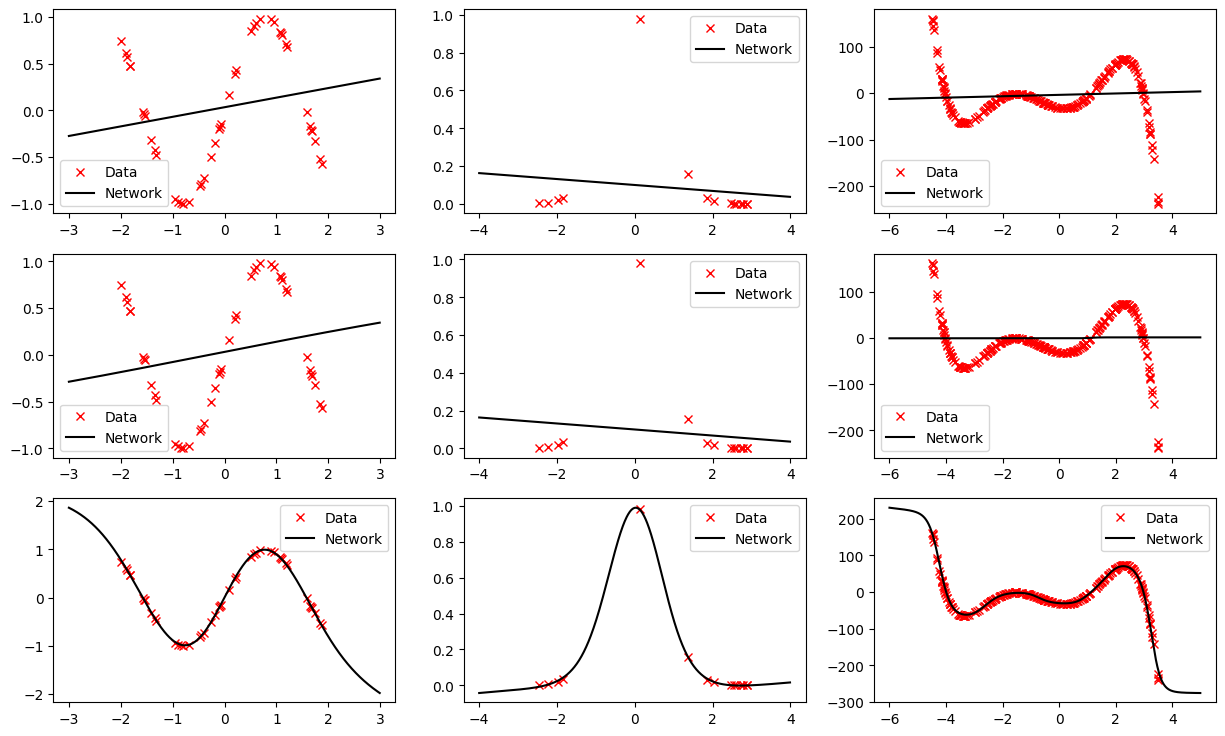

In [17]:
# create one large figure
figure = pyplot.figure(figsize=(15,9))

# collect optimized parameters
Thetas_star = [
    [Theta0_star_N0, Theta1_star_N0, Theta2_star_N0],
    [Theta0_star_N1, Theta1_star_N1, Theta2_star_N1],
    [Theta0_star_N2, Theta1_star_N2, Theta2_star_N2]
]

# plotting ranges
ranges = [[-3,3],[-4,4],[-6,5]]

# iterate over the model types
for model_type in range(3):
    # iterate over the datasets
    for i, X in enumerate([X0, X1, X2]):
        # activate correct plot
        pyplot.subplot(3, 3, 3*model_type+i+1)
        # call the plot function with the correct dataset with their ranges, and model type with their trained Theta parameters
        Theta = Thetas_star[model_type][i]
        R = ranges[i]

        plot(X, model_type, Theta, R)

pyplot.show()